# 02 — System model, infrastructure stages, and pathways

This notebook demonstrates how the transport model, infrastructure stages, and decision pathways are implemented for the SBB MehrSpur case study. The notebook serves as a demonstrative tutorial, which you should adapt to your own case study.

As mentioned in the exercise sheets, you will be presented with different types of calculations and tasks:
- **Tutorials/Supporting task (optional):** building understanding but are not meant as report deliverable.
- **Mandatory/Expected task:** producing a definition, assumption, or result needed later in the project.
- **Advanced task (optional):** extends the model beyond the supplied example.


## Main learning objectives (check exercise sheet phase 2 in for more details)

In this notebook, we will focus primarily on:

1. understanding the underlying transport simulation by defining and inspecting its network, calculating OD matrices, modal splits and traffic assignment;
2. identifying the parameters that control demand, utilities, physical performance, and costs;
3. define infrastructure stages and their impacts, visualize such modifications on the transport network;
4. define simple, static pathways as plans for deploying stages and visualise their evolution over time.


## Scope

This notebook is deliberately deterministic. It contains **no uncertainty sampling, scenario ensembles, fan charts, or trend analysis** which will be explored in the next Phases of the semester. We use fixed nominal assumptions and inspect two snapshots: Year 1 for calibration and Year 40 for comparing alternatives. Pathways describe when stages would be deployed, but their performance under uncertain futures is left to later phases.



## Setup

Run this notebook from either the repository root or the `notebooks` folder. The spatial cells use GeoPandas and Lonboard; install the root `requirements.txt` in the supplied Python 3.11 / NumPy 1.26 transport environment.

The setup cell below imports only lightweight notebook helpers. Large transport files and assignment libraries are loaded later, and only when their readiness checks pass.


In [1]:
import sys
import importlib
from pathlib import Path

# Install the shared project requirements into the active notebook kernel
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
%pip install --quiet -r "$PROJECT_ROOT/requirements.txt"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lonboard

# 1. Set up project directories
CODE_DIR = PROJECT_ROOT / "code"
FIGURES_DIR = PROJECT_ROOT / "figures"
sys.path.insert(0, str(CODE_DIR)) 

# 2. Import project modules
import parameters as p
import stages as stages_module
import simulation_engine as m
import transport_model_interface as tmi
import pathways

# 3. Reload local modules so live edits in .py files are picked up immediately
for module in [p, stages_module, m, tmi]:
    importlib.reload(module)

# General planning parameters
from parameters import N_YEARS, DISCOUNT_RATE

# Notebook configuration
import time as _time; _NB_START = _time.perf_counter()
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + c:\Users\kizal\AppData\Local\Programs\Python\Python313\python.exe C:\Users\kizal\AppData\Local\Temp\pip-install-uy8z1v5z\numpy_4637428cadd74b53af010c95cd8298a1\vendored-meson\meson\meson.py setup C:\Users\kizal\AppData\Local\Temp\pip-install-uy8z1v5z\numpy_4637428cadd74b53af010c95cd8298a1 C:\Users\kizal\AppData\Local\Temp\pip-install-uy8z1v5z\numpy_4637428cadd74b53af010c95cd8298a1\.mesonpy-bxs9_oe6 -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\kizal\AppData\Local\Temp\pip-install-uy8z1v5z\numpy_4637428cadd74b53af010c95cd8298a1\.mesonpy-bxs9_oe6\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\kizal\AppData\Local\Temp\pip-install-uy8z1v5z\numpy_4637428cadd74b53af010c95cd8298a1
      Build dir: C:\Users\kizal\AppData\Local\Temp\pip-install-uy8

Note: you may need to restart the kernel to use updated packages.


# Part 1 — How the system model works

## 1.1 What are we modelling? (tutorial/supporting task)

The model represents passenger trips during the evening peak hour (17:00–18:00) within the Canton of Zürich, using 1,223 spatial zones and a reduced road-assignment cordon around the Zürich–Winterthur corridor. Its four-step structure comprises trip generation, trip distribution, mode choice, and traffic assignment.

For each origin–destination (OD) pair, the model answers:

1. How many trips need to be made?
2. How attractive are the available modes (Car, Public Transport, Bike, Walk) based on real network travel times?
3. What share of trips chooses each mode?
4. What transport outcomes, capacity constraints, and societal costs follow from these choices?

The main components are:

| Component | Representation | Main output |
|---|---|---|
| Network | [Directed links, nodes, connectors, and network attributes](../IP_course_FSM-main/network.py#L183) | Route topology and link attributes |
| Travel demand | [Spatial OD matrix preparation for the 1,223 model zones](../IP_course_FSM-main/demand_preparation.py#L99) | Demand by spatial OD pair |
| Mode attractiveness/disutility | [Mode skims and utility inputs](../IP_course_FSM-main/network.py#L444) and [perceived travel-time policies](../IP_course_FSM-main/travel_times.py#L129) | Utility by mode and OD pair |
| Mode choice | [Multinomial-logit mode split](../IP_course_FSM-main/mode_choice_zurich.py#L38) | Car, PT, Bike, and Walk mode shares |
| Assignment | [Shortest-path and BPR assignment](../IP_course_FSM-main/trip_assignment_zurich.py#L98) | Flow, V/C, time, and delay by road link |
| Infrastructure | [Stage definitions and railway expansion effects](../code/stages.py#L121) and [intervention application](../IP_course_FSM-main/interventions.py#L228) | Changed modal split, assignment and physical indicators |
| Impact calculation | [Annual physical indicators and societal costs](../code/simulation_engine.py#L51) | Annual societal costs |

The calculation chain is:

`Spatial demand + skims + stage interventions → utilities → five-mode OD matrices → road assignment → BPR link times → updated car skim ↺ mode choice → physical and societal impacts`

The feedback arrow is important: the main simulation recomputes modal split from OD-specific congested car times during MSA. A separate fixed-demand dashboard later in this notebook isolates route assignment for teaching and diagnosis.

This notebook concentrates on this chain at a fixed point in time. It does not entail temporal trends or uncertainty, which will be the core of future analyses.

For more detailed technical documentation about the model:

- To understand how the MehrSpur simulation and 40-year pathway model works go to `code/README.md`
- To understand how the underlying Canton Zürich transport model works go to `IP_course_FSM-main/README.md`


## 1.2 Input Data and Simulation Setup (tutorial/supporting task)

This section verifies that all required input datasets (FSM zone definitions, baseline travel times, network distance skims, and daily demand matrices) are properly loaded.

### Structure of the Transport Model in this Notebook
* **Multimodal Mode Choice:** Evaluates travel choices across five alternatives (*Drive*, *Walk*, *Bicycle*, *PT with walk access*, and *PT with bike access*) using a calibrated Multinomial Logit model.
* **Corridor Extraction:** Filters Canton-wide matrices to trips within and intersecting the Zürich–Winterthur corridor to calculate physical indicators (passenger trips, modal shares, vehicle-kilometers, travel times, and $\text{CO}_2$ emissions).
* **Infrastructure Interventions:** Represents project stages by applying targeted percentage changes to baseline travel times, wait times, and transfer penalties as specified in `stages.py`.


In [2]:
from IPython.display import HTML, display

# 1. Check data readiness
transport_status = tmi.transport_input_status(PROJECT_ROOT)
TRANSPORT_FLAGS = tmi.readiness_flags(transport_status)

display(transport_status)
display(HTML(tmi.readiness_message(transport_status)))

# 2. Load the transport context
ctx = None
TRANSPORT_LOAD_ERROR = None

if TRANSPORT_FLAGS["mode_choice"]:
    try:
        ctx = tmi.load_transport_context(PROJECT_ROOT)
    except Exception as error:
        TRANSPORT_LOAD_ERROR = f"{type(error).__name__}: {error}"
        display(HTML(
            "<div style='padding:10px;border-left:5px solid #b71c1c;background:#ffebee'>"
            "<b>The files exist, but the transport model could not load them:</b><br>"
            f"<code>{TRANSPORT_LOAD_ERROR}</code>"
            "</div>"
        ))
else:
    display(HTML(
        "<div style='padding:10px;border-left:5px solid #c47f00;background:#fff8e1'>"
        "<b>Cannot load model:</b> Required input files are missing from <code>input_data/prepared/</code>."
        "</div>"
    ))


,item,required,present,relative_path,purpose
0,Zones,True,True,IP_course_FSM-main\input_data\prepared\zones.p...,"1,223 spatial zones & attributes"
1,Passenger & Background Demand,True,True,IP_course_FSM-main\input_data\prepared\demand....,OD matrices
2,Multimodal Skims,True,True,IP_course_FSM-main\input_data\prepared\skims.p...,Travel times & distances
3,Road Network,True,True,IP_course_FSM-main\input_data\prepared\assignm...,Road links and nodes
4,Mode-choice Parameters,True,True,IP_course_FSM-main\config\mode_choice.json,Logit coefficients


## 1.3 Corridor & Road Network Setup (tutorial/supporting task)

Below, we want to quickly show you the full network at the cantonal scale. This first map is deliberately **pre-assignment** and meant to show you the structure of the network. 

You can select a link characteristic from the dropdown menu and inspect it. Useful distinctions:

- free-flow time is the time before congestion;
- directional capacity is an hourly link property, not the assigned load;
- lanes, speed and road class describe supply;
- no route choice, BPR delay or equilibrium calculation has run yet.


In [3]:
from IPython.display import HTML, display

FULL_NETWORK_MAP = None
FULL_NETWORK_MAP_ERROR = None

if ctx is not None:
    try:
        FULL_NETWORK_MAP = tmi.full_network_explorer(ctx)

        if FULL_NETWORK_MAP is not None:
            display(FULL_NETWORK_MAP)
        else:
            display(HTML(
                "<div style='padding:10px;border-left:5px solid #c47f00;"
                "background:#fff8e1'>"
                "<b>Full-network map unavailable.</b><br>"
                "The transport context was loaded, but the map function "
                "did not return a visualization."
                "</div>"
            ))

    except Exception as error:
        FULL_NETWORK_MAP_ERROR = f"{type(error).__name__}: {error}"

        display(HTML(
            "<div style='padding:10px;border-left:5px solid #b71c1c;"
            "background:#ffebee'>"
            "<b>The transport context loaded successfully, but the "
            "full-network map could not be created.</b><br>"
            f"<code>{FULL_NETWORK_MAP_ERROR}</code><br><br>"
            "Check that the geospatial and visualization dependencies "
            "(including <code>geopandas</code>, <code>lonboard</code>, and "
            "<code>ipywidgets</code>) are installed in the active notebook kernel."
            "</div>"
        ))

else:
    reason = (
        TRANSPORT_LOAD_ERROR
        if TRANSPORT_LOAD_ERROR is not None
        else "The transport context is not available."
    )

    display(HTML(
        "<div style='padding:10px;border-left:5px solid #c47f00;"
        "background:#fff8e1'>"
        "<b>Full-network map skipped.</b><br>"
        "Complete the transport-model preflight and resolve the loading "
        "problem before running this cell.<br>"
        f"<code>{reason}</code>"
        "</div>"
    ))

We've now seen the network at the cantonal level. However, we want to reduce it so that it fits our specific area of interest.

In this project, we only simulate traffic along the **MehrSpur corridor** (Zürich–Winterthur). To keep the traffic assignment fast and responsive, we do not simulate the entire Canton of Zürich road network. Instead, the model clips the network to the MehrSpur core municipalities plus the configured 500 m spatial buffer.

**You are now expected to define a road network for your specific case study area.**

**IMPORTANT: clipping the network by selecting the interested Municipalities is just ONE way of reducing the road network. You can inspect more advanced approaches that further simplify the network, given your infrastructural interventions** 

This clipped boundary is called a **cordon**. To handle trips that start or end outside it, the model identifies boundary crossings and selects direction-compatible **gates** (entry and exit points), using road capacity, a configured 500 m minimum separation, and a maximum gate count.

The Canton-wide passenger demand (i.e. the OD-pairs) is then simplified into four categories:
1. **Internal → Internal**: Trips entirely within the MehrSpur corridor.
2. **Gate → Internal**: Inbound trips entering the corridor from the rest of the Canton.
3. **Internal → Gate**: Outbound trips leaving the corridor.
4. **Gate → Gate**: Pass-through traffic crossing the corridor (calibrated at 5% local share).

Enhancing network for MehrSpur...
✓ Loaded cached detailed corridor network from mehrspur_detailed_network.pkl
  • Simulating Stage 0 (Stage 0 – Baseline Network) with dynamic MSA route assignment...
  • [Simulation] Extracting corridor metrics...

✅ Baseline network (Stage 0) simulated successfully!


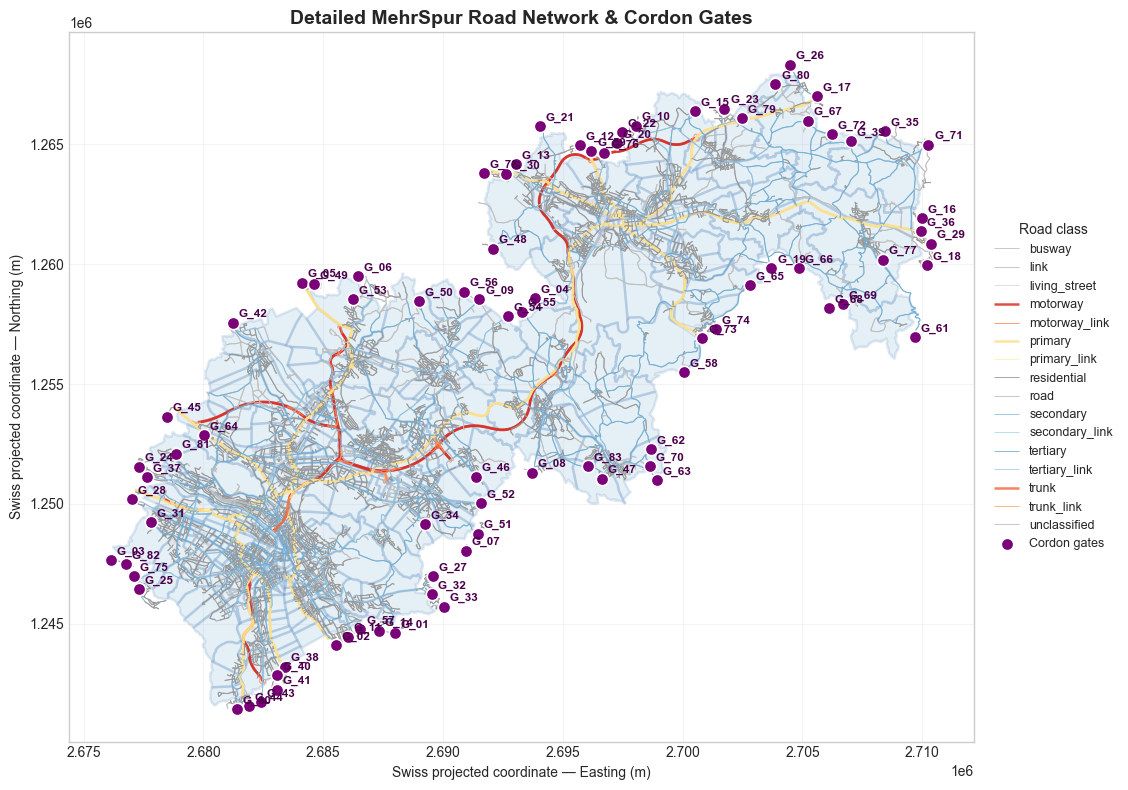

In [4]:
# 1. Enhance the baseline network with high-detail OpenStreetMap roads
project_name = "MehrSpur"
corridor_municipalities = p.CORRIDOR_MUNICIPALITIES
cache_file = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / f"{project_name.lower()}_detailed_network.pkl"
)

if ctx is None:
    raise RuntimeError(
        "The transport context is not available. "
        "Complete the transport-model preflight before running this cell."
    )

print(f"Enhancing network for {project_name}...")

# Use the cached detailed network when available.
# OpenStreetMap is downloaded only if the cache does not exist.
tmi.ASSIGNMENT_SETTINGS["force_regenerate_corridor_network"] = False

ctx = tmi.load_detailed_corridor_network(
    ctx,
    corridor_municipalities=corridor_municipalities,
    cache_path=cache_file,
    allow_download=True,
)

# Build the corridor context used by maps, gates, and diagnostic tables.
MEHRSPUR = tmi.build_mehrspur_corridor(
    ctx,
    corridor_municipalities=corridor_municipalities,
)

# Use the explicit MSA assignment and feed its OD-specific congested travel
# times back into mode choice in the main simulation.
tmi.ASSIGNMENT_SETTINGS.update({
    "method": "MSA",
    "modal_feedback": True,
    "max_iterations": 8,
})


# 2. Run Baseline Simulation (Stage 0 only) we will look at the "stages" 
# in more detail in later parts of this notebook. For now, just consider 
# "Stage 0" as the current baseline network with no additional infrastructure 
# or policy interventions. 
# The simulation will assign routes dynamically using the MSA algorithm.
stages = stages_module.get_stages(p.NOMINAL_PARAMS)

print(
    f"  • Simulating Stage 0 ({stages[0]['name']}) "
    "with dynamic MSA route assignment..."
)

res_stage0, metrics_stage0 = tmi.run_simulation(
    ctx,
    stage=0,
    stage_specs=stages,
    corridor_municipalities=corridor_municipalities,
)

print("\n✅ Baseline network (Stage 0) simulated successfully!")


# 3. Visualize the Cordon, Road Network, and Gates (Stage 0 Baseline)
if res_stage0 is not None:
    # Interactive WebGL dashboard:
    # map, selectable road attributes, gates, network detail, and OD summaries.
    MEHRSPUR_DASHBOARD = tmi.corridor_dashboard(
        ctx,
        MEHRSPUR,
        demand_matrix=res_stage0.drive_od,
    )
    display(MEHRSPUR_DASHBOARD)

    # Static Stage 0 network plot.
    tmi.static_network_plot(
        context=ctx,
        mode_result=res_stage0,
        corridor_municipalities=corridor_municipalities,
        project_name=project_name,
    )
else:
    display(HTML(
        "<div style='padding:10px;border-left:5px solid #c47f00;"
        "background:#fff8e1'>"
        "<b>Baseline visualization skipped.</b><br>"
        "The Stage 0 simulation did not return a result."
        "</div>"
    ))

### Cordon gates

The model creates candidate gates where road links cross the outer boundary of the MehrSpur corridor. Nearby crossings are grouped and filtered according to road capacity, minimum gate separation, and the maximum number of gates.

External trips enter or leave the local network through the nearest direction-compatible gate.

To check whether enough gates are retained, compare several configurations. The selected number is adequate when important boundary roads are represented and increasing the number of gates changes demand and congestion results by less than approximately **2–5%**. Synthetic `manual_connector` links should not dominate the selection.

In [5]:
# Test whether the chosen number of cordon gates is sufficient

GATE_CONFIGURATIONS = [
    {"max_gates": 15, "gate_separation_m": 1000.0},
    {"max_gates": 30, "gate_separation_m": 800.0},
    {"max_gates": 40, "gate_separation_m": 500.0},
    {"max_gates": 100, "gate_separation_m": 500.0},
    {"max_gates": 10_000, "gate_separation_m": 0.0},  # all candidate nodes
]

gate_test_rows = []
gate_test_contexts = {}

for config in GATE_CONFIGURATIONS:
    corridor = tmi.build_mehrspur_corridor(
        ctx,
        corridor_municipalities=corridor_municipalities,
        max_gates=config["max_gates"],
        gate_separation_m=config["gate_separation_m"],
    )

    reduced_od, breakdown = tmi.collapse_od_to_gates(
        ctx.baseline_od,
        ctx,
        corridor,
    )

    totals = tmi.gate_totals(reduced_od, corridor)
    total_gate_demand = totals["cordon_total"].sum()

    gate_test_rows.append({
        "max_gates": config["max_gates"],
        "separation_m": config["gate_separation_m"],
        "candidate_nodes": corridor.metadata["candidate_boundary_nodes"],
        "selected_gates": corridor.metadata["selected_gates"],
        "entry_gates": corridor.metadata["entry_gates"],
        "exit_gates": corridor.metadata["exit_gates"],
        "retained_trips: % of total cantonal trips": round(100.0* reduced_od.to_numpy(dtype=float).sum()
                                  / max(ctx.baseline_od.to_numpy(dtype=float).sum(), 1e-9),2,),        "largest_gate_share": (
            totals["cordon_total"].max() / total_gate_demand
            if total_gate_demand > 0
            else 0.0
        ),
        "manual_connector_gates": (
            corridor.gates["highway"]
            .astype(str)
            .eq("manual_connector")
            .sum()
        ),
    })

    gate_test_contexts[
        (config["max_gates"], config["gate_separation_m"])
    ] = corridor

GATE_SENSITIVITY = pd.DataFrame(gate_test_rows)
display(GATE_SENSITIVITY)

,max_gates,separation_m,candidate_nodes,selected_gates,entry_gates,exit_gates,retained_trips: % of total cantonal trips,largest_gate_share,manual_connector_gates
0,15,1000.0,186,15,15,15,62.06,0.257730,0
1,30,800.0,186,30,30,30,62.17,0.136393,0
2,40,500.0,186,40,39,40,62.23,0.135832,0
3,100,500.0,186,82,81,82,62.37,0.075336,0
4,10000,0.0,186,186,182,182,62.48,0.074655,0


After having consulted the inspection above, you can go and change these gate-creation settings in the `transport_model_interface.py`, if needed. 

And if you want to quickly visualize all candidate gates, run this cell below.

In [6]:
ALL_GATE_CANDIDATES = gate_test_contexts[(10_000, 0.0)]
display(tmi.corridor_explorer(ALL_GATE_CANDIDATES))

## 1.4 Baseline Passenger Demand & Desire Lines (tutorial/supporting task + mandatory task)

To understand where people travel along the Zürich–Winterthur corridor, we visualize **desire lines**  and **OD-matrices** at various levels of spatial resolution. 

Below, for instance, you can visualize how trips are distributed if we aggregate them by Municipality and therefore see which ones exhibit the strongest demand.

> **OD-inspection and model validation**
>
> The following analyses help assess whether the model produces plausible travel patterns before its outputs are used in later stages. Compare internal, inbound, outbound, and pass-through demand with independent evidence, such as observed transport data, official statistics, previous studies, CBA assumptions, or projects from earlier course editions.
>
> Differences between sources do not necessarily indicate an error, but they should be identified, investigated, and documented. Unexplained differences in demand may propagate through the analysis and affect modal shares, assigned traffic volumes, congestion levels, travel-time benefits, emissions, and ultimately the CBA results.
>

**IMPORTANT: these values represent peak-hour evening demand in the Canton of Zurich, i.e. only trips happening on a "regular" day between 17:00-18:00**

Here below, you can start inspecting the data by analysing the total number of trips happening between pairs of municipalities.

In [7]:
MUNICIPALITY_OD_FIGURE = tmi.municipality_od_explorer(
    ctx,
    p.CORRIDOR_MUNICIPALITIES,
)

display(MUNICIPALITY_OD_FIGURE)

#### Desire-line map

The desire-line map shows the spatial relationship between origins and destinations. Desire lines are not routes that go through the road network. They show where demand originates and ends but not which roads travellers use.

The category and flow-range controls can be used to focus on specific movements. For browser performance, only the largest selected flows are displayed. This visualization limit does not remove trips from the OD matrix or from the transport simulation.

In this case below, centroids of municipal polygons are used as references for connecting desire lines.

In [8]:
MUNICIPALITY_FLOW_MAP = tmi.municipality_flow_map_explorer(
    ctx,
    p.CORRIDOR_MUNICIPALITIES,
    min_trips=1,
    max_flows=300,
    trip_bin_edges=[
        1,
        10,
        25,
        50,
        100,
        250,
        500,
        1_000,
        np.inf,
    ],
)

display(MUNICIPALITY_FLOW_MAP)

Desire lines help us understand the general structure. However, you might want to go into more detail about the number and distribution of trips.

We can, for instance, differentiate between:
- trips between internal zones;
- trips entering through a gate;
- trips leaving through a gate;
- an estimated share of pass-through trips between gates.

External origins and destinations are assigned to their nearest direction-compatible gate. The resulting matrix is used only to represent demand at the corridor scale; the original canton-wide matrix remains unchanged.

In [9]:
# Collapse the canton-wide baseline OD matrix into internal zones and cordon gates
# and distinguish between trips that are internal to the canton 
# and those that cross the cordon.
BASELINE_CORDON_OD, BASELINE_CORDON_BREAKDOWN = tmi.collapse_od_to_gates(
    ctx.baseline_od,
    ctx,
    MEHRSPUR,
    passthrough_fraction=tmi.DEFAULT_PASSTHROUGH_FRACTION,
)

display(BASELINE_CORDON_BREAKDOWN)

# Visualize the collapsed OD matrix with an interactive explorer
display(
    tmi.od_matrix_explorer(
        BASELINE_CORDON_OD,
        MEHRSPUR,
    )
)

,category,trips,share_of_retained
0,internal -> internal,315935.281309,0.768827
1,gate -> internal,44932.424635,0.109343
2,internal -> gate,46171.700874,0.112359
3,gate -> gate (pass-through),3892.067191,0.009471


    'data': [{'colorbar': {'title': {'text': 'Trips'}},
              'colorscal…

And, if you want to inspect the desire lines in more detail, you can run the cell below, which allows you to visualize each line that connects an origin directly to a destination. 

- line direction indicates the direction of travel;
- line width represents the relative number of trips;
- colour represents the flow-size quantile;
- purple points represent cordon gates.

In [10]:
# You can adjust the number of bins, maximum flows, 
# and minimum trips to explore different levels of 
# detail in the corridor flow map.
display(
    tmi.corridor_flow_map_explorer(
        BASELINE_CORDON_OD,
        MEHRSPUR,
        n_bins=5,
        max_flows=250,
        min_trips=50,
    )
)

    'data': [{'fill': 'toself',
              'fillcolor': 'rgba(35,120,180,0.12…

## 1.5 Baseline Modal Split (mandatory task)

Before simulating infrastructure interventions (such as the Brüttenertunnel, 15-minute frequency rhythm, and station mobility hubs), we inspect the baseline modal split (Stage 0) for daily trips within the MehrSpur corridor.

The multinomial logit model determines mode choice (Car, Public Transport, Bike, Walk) based on generalized travel costs (in-vehicle time, waiting time, access/egress, and transfer penalties).

**Trip-based vs. PKM-based (Distance-weighted) Modal Split**

In regional transport models, a 2 km local walk to the bakery counts as exactly "one trip"—the same as a 25 km commute on the InterCity train. If we evaluate the whole corridor using pure trip counts, the massive volumes of local walking and cycling heavily dilute the performance of the railway.

To isolate the "strategic" signal of our interventions (like the Brüttenertunnel), our primary evaluation metric uses **Passenger-Kilometers (PKM) filtered for trips > 5 km**. This correctly weights long-distance motorized trips where the railway actually competes with the A1 highway, giving us a sharp, high-fidelity indicator for project success. 

Below, we compare the raw Trip-based share against the PKM-based share.


MehrSpur Corridor Baseline Modal Split:


,Mode,Trips (Raw),Trip Share,PKM Share (>5km)
0,Car (Driver),"138,114",33.9%,68.1%
1,Public Transport,"74,077",18.2%,25.2%
2,Bicycle,"54,235",13.3%,4.8%
3,Walking,"140,614",34.5%,1.9%



Modal Split for Key Corridor Relations (Trip-based):


,OD relation,total_trips,car_trips,pt_trips,bike_trips,walk_trips,car_share,pt_share,bike_share,walk_share
0,Zürich → Winterthur,"2,018","1,044",973,1,0,51.7%,48.2%,0.1%,0.0%
1,Winterthur → Zürich,"1,850","1,037",812,1,0,56.1%,43.9%,0.1%,0.0%
2,Zürich → Airport / Glattal,"12,332","6,213","2,963","1,517","1,640",50.4%,24.0%,12.3%,13.3%
3,Winterthur → Airport / Glattal,"1,991","1,699",257,33,2,85.4%,12.9%,1.7%,0.1%


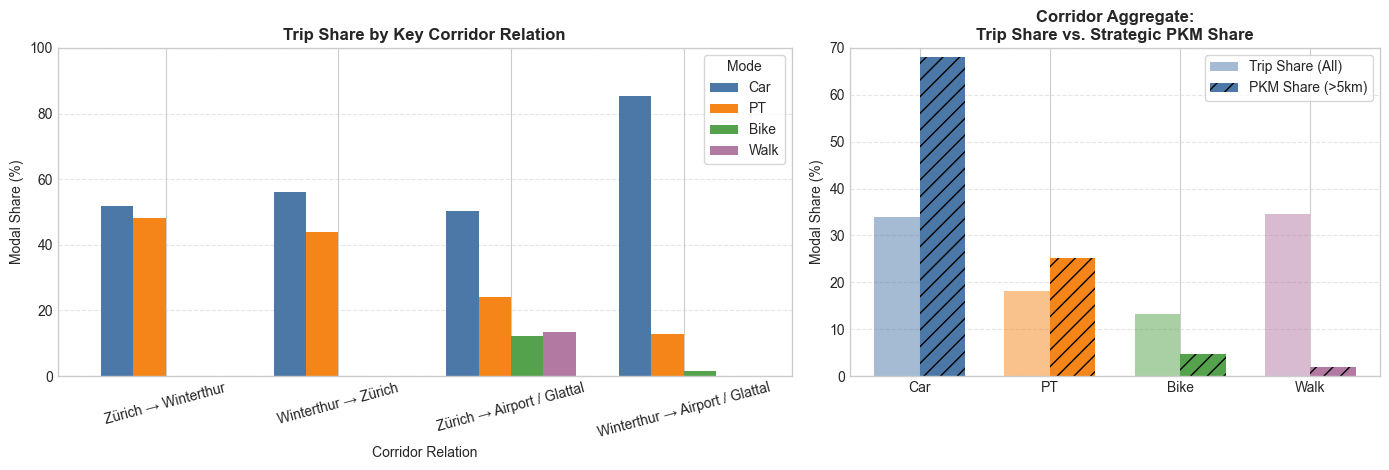

In [11]:
# 1. Overall MehrSpur corridor internal modal split (Trip vs PKM Comparison)
# The metrics dictionary automatically computes both pure trips and spatially filtered PKM.
split_data = [
    {
        "Mode": "Car (Driver)",
        "Trips (Raw)": metrics_stage0["car_trips"],
        "Trip Share": metrics_stage0["car_share_trips"],
        "PKM Share (>5km)": metrics_stage0["car_share"],
    },
    {
        "Mode": "Public Transport",
        "Trips (Raw)": metrics_stage0["pt_trips"],
        "Trip Share": metrics_stage0["pt_share_trips"],
        "PKM Share (>5km)": metrics_stage0["pt_share"],
    },
    {
        "Mode": "Bicycle",
        "Trips (Raw)": metrics_stage0["bike_trips"],
        "Trip Share": metrics_stage0["bike_share_trips"],
        "PKM Share (>5km)": metrics_stage0["bike_share"],
    },
    {
        "Mode": "Walking",
        "Trips (Raw)": metrics_stage0["walk_trips"],
        "Trip Share": metrics_stage0["walk_share_trips"],
        "PKM Share (>5km)": metrics_stage0["walk_share"],
    },
]

corridor_split = pd.DataFrame(split_data)
print("MehrSpur Corridor Baseline Modal Split:")
display(corridor_split.style.format({
    "Trips (Raw)": "{:,.0f}", 
    "Trip Share": "{:.1%}", 
    "PKM Share (>5km)": "{:.1%}"
}))

# 2. Modal split for key corridor relations (Raw Trips)
key_pairs = [
    ("Zürich", "Winterthur"),
    ("Winterthur", "Zürich"),
    ("Zürich", "Airport / Glattal"),
    ("Winterthur", "Airport / Glattal"),
]
od_split = tmi.corridor_od_summary(ctx, res_stage0, key_pairs, macro_regions=p.CORRIDOR_REGIONS)
print("\nModal Split for Key Corridor Relations (Trip-based):")
display(od_split.style.format({
    "total_trips": "{:,.0f}",
    "car_trips": "{:,.0f}",
    "pt_trips": "{:,.0f}",
    "bike_trips": "{:,.0f}",
    "walk_trips": "{:,.0f}",
    "car_share": "{:.1%}",
    "pt_share": "{:.1%}",
    "bike_share": "{:.1%}",
    "walk_share": "{:.1%}",
}))

# 3. Modal split charts: (1) Key OD Relations vs. (2) Aggregate Corridor Baseline
mode_names = ["Car", "PT", "Bike", "Walk"]
mode_cols = ["car_share", "pt_share", "bike_share", "walk_share"]
colors = ["#4c78a8", "#f58518", "#54a24b", "#b279a2"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1.8, 1.3]})

# --- Left Plot: Relation-level modal shares ---
plot_data = od_split.set_index("OD relation")[mode_cols].mul(100)
plot_data.columns = mode_names
plot_data.plot(kind="bar", ax=axes[0], color=colors, width=0.75, edgecolor="none")
axes[0].set_title("Trip Share by Key Corridor Relation", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Corridor Relation", fontsize=10)
axes[0].set_ylabel("Modal Share (%)", fontsize=10)
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(title="Mode", frameon=True)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# --- Right Plot: PKM vs Trip Share Comparison ---
x_indices = np.arange(len(mode_names))
width = 0.35

axes[1].bar(x_indices - width/2, corridor_split["Trip Share"].mul(100), width, label='Trip Share (All)', color=[c for c in colors], alpha=0.5)
axes[1].bar(x_indices + width/2, corridor_split["PKM Share (>5km)"].mul(100), width, label='PKM Share (>5km)', color=colors, hatch="//")

axes[1].set_title("Corridor Aggregate:\nTrip Share vs. Strategic PKM Share", fontsize=12, fontweight="bold")
axes[1].set_xticks(x_indices)
axes[1].set_xticklabels(mode_names)
axes[1].set_ylabel("Modal Share (%)", fontsize=10)
axes[1].set_ylim(0, 70)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
axes[1].legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


> **Modal-split validation**
>
> After reviewing these results, you can further inspect the modal split for different demand categories, such as internal, inbound, outbound, and pass-through trips for your case study area. 
>
> Compare the resulting mode shares with available reference values, including observed transport data, official statistics, previous studies, and results from earlier course editions.
>
> Consider whether differences are plausible given trip distance, spatial context, transport availability, and the model assumptions. Any relevant discrepancy should be investigated and documented, as modal shares directly influence network demand, congestion, travel-time benefits, emissions, and the subsequent CBA.

### Exploration: Utilities, $\beta$ Parameters, and Modal Split (tutorial/supporting task)

> Below is a quick explaination of how modal splits are computed. You can play with the interactive widget below, in order to get a sense of the relevance and role of key parameters, which we will use in later computations and notebooks.

Travelers choose modes based on **utility** ($U$)—a score of relative attractiveness where a higher (less negative) value means greater desirability:

$$U_m = \beta_m + \beta_{TT} \cdot TT_m + \beta_{\text{cost}} \cdot C_m$$

The **Multinomial Logit Model** converts these utilities into choice probabilities:

$$P_m = \frac{\exp(U_m)}{\sum_{k} \exp(U_k)}$$

---

#### What is the $\beta_m$ parameter and how does it affect the results?
* **Intrinsic Preference ($\beta_m$)**: The alternative-specific constant $\beta_m$ captures all unobserved factors independent of travel time and cost (e.g., comfort, flexibility, privacy, weather protection, or prestige).
* **Impact on Modal Split**: Because logit probabilities depend exponentially on utility ($\exp(U_m)$), increasing $\beta_m$ directly raises mode $m$'s attractiveness relative to all alternatives, exponentially pulling demand away from competing modes across the corridor.

Use the sliders below to see how adjusting overall demand, **baseline preferences** ($\beta_{\text{car}}$, $\beta_{\text{PT}}$, $\beta_{\text{bike}}$), and infrastructure stages dynamically shifts corridor modal shares and pkm.


In [12]:
# Interactive mode-choice & parameter sensitivity dashboard — Stage 0 only
corridor_zones = tmi.get_zone_ids_for_municipalities(
    ctx,
    p.CORRIDOR_MUNICIPALITIES,)

stage_0_specs = {
    0: stages[0],}

dashboard_ui, dashboard_state = tmi.mode_choice_dashboard(
    ctx,
    # Keep Stage 0 fixed for now, we will later explore the impact of stages.
    # If you want to come back to this dashboard later, 
    # you can set the display back by writing 'stages' instead of 'stage_0_specs'.
    stage_specs=stage_0_specs,  #here 'stages'
    corridor_zone_ids=corridor_zones,)

display(dashboard_ui)


## 1.6 Dynamic road assignment and congestion feedback

Road assignment loads the **latest car demand from mode choice**, plus fixed background road traffic, onto the reduced MehrSpur network. Passenger car trips are converted to vehicles using the configured occupancy factor; internal, inbound, outbound, and assumed pass-through movements enter through the same zone-and-gate OD matrix.

The local solver uses All-or-Nothing (AoN) shortest paths, the **Method of Successive Averages (MSA)**, and **Bureau of Public Roads (BPR)** volume-delay functions:

$$t_a = t_{a,0} \left[ 1 + \alpha_a \left( \frac{v_a}{c_a} \right)^{\beta_a} \right]$$

* $t_a$: Congested link travel time
* $t_{a,0}$: Free-flow travel time
* $v_a / c_a$: Volume-to-capacity ratio ($V/C$)
* $\alpha_a, \beta_a$: Calibrated BPR link parameters (typically $\alpha = 0.15, \beta = 4.0$)

In each MSA iteration, demand is loaded onto the current shortest paths and averaged with flows from earlier iterations using a $1/k$ step. The controls below let you change the maximum iteration count, OD cutoff, pass-through assumption, and practical **relative L1 flow-change threshold**. This threshold is a transparent stopping diagnostic, not a formal Wardrop-equilibrium gap.

The first dashboard deliberately keeps car demand fixed so that you can inspect the assignment mechanism itself. Use the map selector and clickable links to examine assigned flow, $V/C$, congested time, delay, speed, and capacity. The later coupled dashboard closes the feedback loop and shows how congestion can also change modal split.


In [13]:
# Select the most recent fixed-skims mode-choice result.
mode_result = (
    dashboard_state.get("result")
    if "dashboard_state" in globals()
    and dashboard_state.get("result") is not None
    else tmi.run_transport_mode_choice(
        ctx,
        stage=0,
        stage_specs=stage_0_specs,
        corridor_zone_ids=corridor_zones,
    )
)

# Keep the notebook cell small: demand preparation, MSA, diagnostics,
# convergence chart, audit tables, and the interactive map live in tmi.
ASSIGNMENT_MODE_STATE = {"result": mode_result}
ASSIGNMENT_UI, ASSIGNMENT_STATE = tmi.assignment_dashboard(
    ctx,
    MEHRSPUR,
    ASSIGNMENT_MODE_STATE,
    modal_feedback=False,  # isolate route assignment first
)
display(ASSIGNMENT_UI)


### Checking the MSA iteration limit and stopping threshold

A single convergence trace may be unusually easy or difficult. The diagnostic below repeats the fixed-demand assignment after perturbing total car demand, retained OD cells, and the uncertain pass-through share. It reports the median and interquartile range of the relative L1 flow change and the share of runs that reach each candidate threshold.

Use this test to justify a practical iteration limit and threshold for an interactive teaching model. It does **not** prove a stochastic user equilibrium and it is not a substitute for calibration against observed traffic counts. The default 30-run test can take several minutes on the detailed road network.


,iteration,median,q25,q75
0,1,3590977320535033.000,3126479295093673.500,3838885879852685.500
1,2,0.415,0.357,0.442
2,3,0.163,0.125,0.176
3,4,0.076,0.068,0.081
4,5,0.049,0.043,0.051
5,6,0.037,0.035,0.039
6,7,0.028,0.026,0.032
7,8,0.022,0.021,0.024


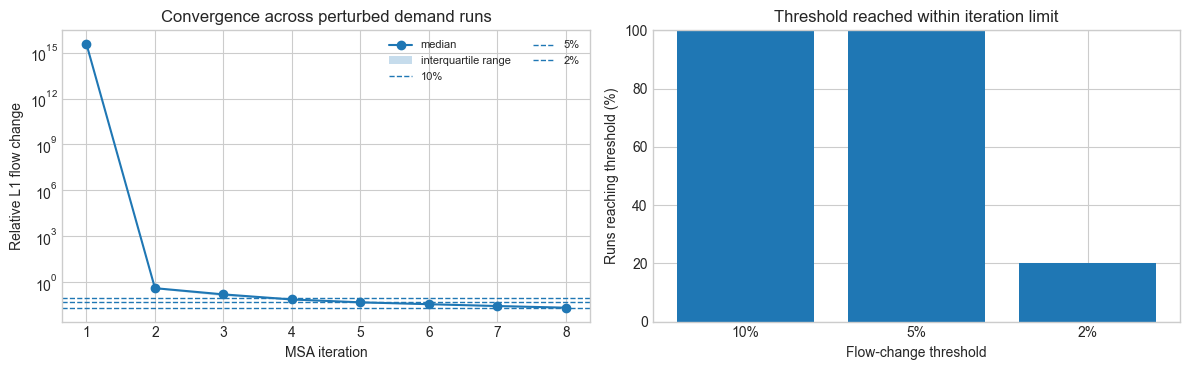

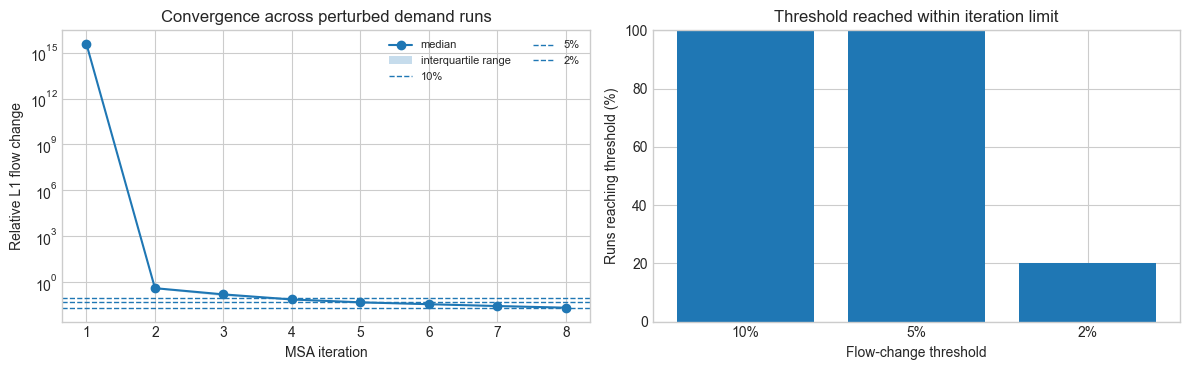

In [14]:
# Numerical stability test for the fixed-demand MSA calculation.
N_CONVERGENCE_RUNS = 30
CONVERGENCE_MAX_ITERATIONS = 8
CONVERGENCE_THRESHOLDS = (0.10, 0.05, 0.02)

MSA_CONVERGENCE = tmi.assignment_convergence_test(
    ctx,
    MEHRSPUR,
    mode_result,
    n_runs=N_CONVERGENCE_RUNS,
    max_iterations=CONVERGENCE_MAX_ITERATIONS,
    thresholds=CONVERGENCE_THRESHOLDS,
)

display(MSA_CONVERGENCE["summary"].style.format({
    "median": "{:.3f}",
    "q25": "{:.3f}",
    "q75": "{:.3f}",
}))
display(tmi.plot_assignment_convergence_test(
    MSA_CONVERGENCE,
    thresholds=CONVERGENCE_THRESHOLDS,
))


### Closing the loop: modal split inside the MSA iteration

The fixed-demand dashboard above updates road routes and link travel times, but it assigns a car OD matrix calculated only once from the original skims. Congestion therefore cannot yet make a traveller switch to public transport, bicycle, walking, or a PT access alternative.

The coupled calculation below closes that loop using the same MSA sequence:

1. BPR functions update every road-link travel time from the current flow.
2. All-or-Nothing shortest paths produce the next link-flow target.
3. A shortest-path sweep records travel time between every internal zone and direction-compatible cordon gate, both at free flow and under the current congestion.
4. The resulting **OD-specific corridor delay** is mapped back to the full 1,223-zone car skim. External origins and destinations use the same entry/exit-gate mappings as the cordon OD reduction.
5. The five-alternative logit model recomputes car, walk, bike, PT+walk, and PT+bike demand. Updated car demand is collapsed to gates and averaged with the same $1/k$ MSA step as link flow.

This is still a local-network approximation: only congestion inside the MehrSpur cordon changes, while the rest of each whole-trip travel time remains fixed. However, different OD pairs receive different delays according to the internal zones and gates their routes actually use; the model does not apply one corridor-wide average delay to every trip.


In [15]:
# Run the same assignment controls with congestion-to-mode-choice feedback.
COUPLED_ASSIGNMENT_UI, COUPLED_ASSIGNMENT_STATE = tmi.assignment_dashboard(
    ctx,
    MEHRSPUR,
    ASSIGNMENT_MODE_STATE,
    modal_feedback=True,
)
display(COUPLED_ASSIGNMENT_UI)


## 1.7 Physical Evaluation Objectives

> 💡 **Note: Why don't we spatially filter Travel Time and Delay?**
> In Section 1.5, we filtered the Modal Split to trips `> 5km` to isolate the strategic behavioral shift. However, for the physical indicators below (Delay, Travel Time, $\text{CO}_2$), we deliberately evaluate the **entire unfiltered corridor network**. 
> Why? Because moving long-distance commuters to rail empties out the A1 highway, which massively reduces congestion for short-distance local drivers too! In a Cost-Benefit Analysis, we must capture this systemic "Decongestion Benefit", so throwing away local trips from the travel time calculation would severely undercount the project's true economic value.

Before evaluating scenarios over the 40-year horizon, we define our core **physical (non-monetised) indicators**. These translate the spatial transport model results into measurable corridor performance metrics.


| Objective | Unit | What it measures |
|---|---|---|
| `avg_travel_time_min` | min/trip | Demand-weighted average door-to-door duration across all modes |
| `congestion_delay_hours` | vehicle-hours | Extra time spent in road bottlenecks beyond free-flow |
| `co2_tonnes` | tonnes $\text{CO}_2$ | Direct tailpipe emissions from car travel |
| `total_demand` | trips | Total passenger volume traveling in the corridor |


In [16]:
import pandas as pd
import numpy as np
import parameters as p
import simulation_engine as m

# 1. Retrieve baseline metrics and mode results for Stage 0
if "metrics_stage0" in globals() and "res_stage0" in globals():
    base_metrics = metrics_stage0
    mode_res0 = res_stage0
elif "stage_metrics" in globals() and 0 in stage_metrics and "stage_results" in globals() and 0 in stage_results:
    base_metrics = stage_metrics[0]
    mode_res0 = stage_results[0]
else:
    stages_spec = globals().get("stages", stages_module.get_stages(p.NOMINAL_PARAMS))
    mode_res0, base_metrics = tmi.run_simulation(
        ctx, 
        stage=0, 
        stage_specs=stages_spec, 
        corridor_zone_ids=corridor_zones,
        corridor_municipalities=corridor_municipalities
    )

# 2. Extract Year 1 and Year 40 simulation data using simulate_year (with MSA)
g_cum_40 = p.DEMAND_GROWTH_Y40
scale_y1 = 1.0
scale_y40 = 1.0 + g_cum_40

# Pass spatial context and mode_result so MSA assignment runs for Year 1 and Year 40
res_y1 = m.simulate_year(
    base_metrics, 
    stage=0, 
    year_idx=0, 
    g_cum=0.0,
    context=ctx,
    mode_result=mode_res0,
    corridor_municipalities=corridor_municipalities
)
res_y40 = m.simulate_year(
    base_metrics, 
    stage=0, 
    year_idx=39, 
    g_cum=g_cum_40,
    context=ctx,
    mode_result=mode_res0,
    corridor_municipalities=corridor_municipalities
)

delay_y1_peak = res_y1["congestion_delay_hours"] / p.PEAK_TO_ANNUAL
delay_y40_peak = res_y40["congestion_delay_hours"] / p.PEAK_TO_ANNUAL

# 3. Helper function to calculate mode-specific metrics (with Trip and PKM split)
def get_mode_breakdown(scale: float, extra_delay_peak: float) -> pd.DataFrame:
    # Demand (Peak Hour)
    car_trips = base_metrics["car_trips"] * scale
    pt_trips = base_metrics["pt_trips"] * scale
    bike_trips = base_metrics["bike_trips"] * scale
    walk_trips = base_metrics["walk_trips"] * scale
    total_trips = base_metrics["total_trips"] * scale
    
    # Travel Time (Average minutes per trip)
    tt_car_hours = base_metrics["car_tt_hours"] * scale + extra_delay_peak
    avg_tt_car = (tt_car_hours / max(car_trips, 1e-6)) * 60.0
    avg_tt_pt = (base_metrics["pt_tt_hours"] / max(base_metrics["pt_trips"], 1e-6)) * 60.0
    
    # Overall average travel time (door-to-door weighted average across motorized modes)
    avg_tt_system = (((tt_car_hours + (base_metrics["pt_tt_hours"] * scale)) / max(car_trips + pt_trips, 1e-6)) * 60.0)
    
    # Emissions & Delay
    co2_car = (base_metrics["car_dist_km"] * scale * p.P_CO2) / 1000.0
    
    data = [
        {
            "Mode": "Car (Driver)",
            "Peak Trips": car_trips,
            "Trip Share": car_trips / total_trips,
            "PKM Share (>5km)": base_metrics.get("car_share", car_trips / total_trips),
            "Avg Travel Time": avg_tt_car,
            "Peak Delay (h)": extra_delay_peak,
            "Peak CO2 (t)": co2_car,
        },
        {
            "Mode": "Public Transport",
            "Peak Trips": pt_trips,
            "Trip Share": pt_trips / total_trips,
            "PKM Share (>5km)": base_metrics.get("pt_share", pt_trips / total_trips),
            "Avg Travel Time": avg_tt_pt,
            "Peak Delay (h)": 0.0,
            "Peak CO2 (t)": 0.0,
        },
        {
            "Mode": "Bicycle",
            "Peak Trips": bike_trips,
            "Trip Share": bike_trips / total_trips,
            "PKM Share (>5km)": base_metrics.get("bike_share", bike_trips / total_trips),
            "Avg Travel Time": np.nan,
            "Peak Delay (h)": 0.0,
            "Peak CO2 (t)": 0.0,
        },
        {
            "Mode": "Walking",
            "Peak Trips": walk_trips,
            "Trip Share": walk_trips / total_trips,
            "PKM Share (>5km)": base_metrics.get("walk_share", walk_trips / total_trips),
            "Avg Travel Time": np.nan,
            "Peak Delay (h)": 0.0,
            "Peak CO2 (t)": 0.0,
        },
        {
            "Mode": "--- Total / System Average ---",
            "Peak Trips": total_trips,
            "Trip Share": 1.0,
            "PKM Share (>5km)": 1.0,
            "Avg Travel Time": avg_tt_system,
            "Peak Delay (h)": extra_delay_peak,
            "Peak CO2 (t)": co2_car,
        },
    ]
    return pd.DataFrame(data).set_index("Mode")

# 4. Generate Tables
df_y1 = get_mode_breakdown(scale_y1, delay_y1_peak)
df_y40 = get_mode_breakdown(scale_y40, delay_y40_peak)

# 5. Display Mode-by-Mode Results (Peak Hour Snapshot)
format_dict = {
    "Peak Trips": "{:,.0f} trips",
    "Trip Share": "{:.1%}",
    "PKM Share (>5km)": "{:.1%}",
    "Avg Travel Time": "{:.1f} min",
    "Peak Delay (h)": "{:,.1f} h",
    "Peak CO2 (t)": "{:,.1f} t",
}

print("⏱️ Year 1: Mode-Specific Performance (Evening Peak Hour Snapshot):")
display(df_y1.style.format(format_dict, na_rep="-"))

print("\n⏱️ Year 40: Mode-Specific Performance (Evening Peak Hour Snapshot):")
display(df_y40.style.format(format_dict, na_rep="-"))

# 6. Combined Comparison Table (Annual Totals x PEAK_TO_ANNUAL)
annual_comparison = pd.DataFrame({
    "Year 1 Trips (Annual)": df_y1["Peak Trips"] * p.PEAK_TO_ANNUAL,
    "Year 40 Trips (Annual)": df_y40["Peak Trips"] * p.PEAK_TO_ANNUAL,
    "Year 1 Avg TT": df_y1["Avg Travel Time"],
    "Year 40 Avg TT": df_y40["Avg Travel Time"],
    "Year 1 Delay (Annual h)": df_y1["Peak Delay (h)"] * p.PEAK_TO_ANNUAL,
    "Year 40 Delay (Annual h)": df_y40["Peak Delay (h)"] * p.PEAK_TO_ANNUAL,
    "Year 1 CO2 (Annual t)": df_y1["Peak CO2 (t)"] * p.PEAK_TO_ANNUAL,
    "Year 40 CO2 (Annual t)": df_y40["Peak CO2 (t)"] * p.PEAK_TO_ANNUAL,
})

print(f"\n📊 Multi-Year Modal Comparison (Annual Totals - {p.PEAK_TO_ANNUAL:,.0f} peak hours/year):")
display(annual_comparison.style.format({
    "Year 1 Trips (Annual)": "{:,.0f}",
    "Year 40 Trips (Annual)": "{:,.0f}",
    "Year 1 Avg TT": "{:.1f} min",
    "Year 40 Avg TT": "{:.1f} min",
    "Year 1 Delay (Annual h)": "{:,.0f} h",
    "Year 40 Delay (Annual h)": "{:,.0f} h",
    "Year 1 CO2 (Annual t)": "{:,.0f} t",
    "Year 40 CO2 (Annual t)": "{:,.0f} t",
}, na_rep="-"))



⏱️ Year 1: Mode-Specific Performance (Evening Peak Hour Snapshot):


,Peak Trips,Trip Share,PKM Share (>5km),Avg Travel Time,Peak Delay (h),Peak CO2 (t)
Mode,,,,,,
Car (Driver),"138,114 trips",33.9%,68.1%,11.4 min,"2,951.7 h",184.2 t
Public Transport,"74,077 trips",18.2%,25.2%,12.9 min,0.0 h,0.0 t
Bicycle,"54,235 trips",13.3%,4.8%,-,0.0 h,0.0 t
Walking,"140,614 trips",34.5%,1.9%,-,0.0 h,0.0 t
--- Total / System Average ---,"407,039 trips",100.0%,100.0%,11.9 min,"2,951.7 h",184.2 t



⏱️ Year 40: Mode-Specific Performance (Evening Peak Hour Snapshot):


,Peak Trips,Trip Share,PKM Share (>5km),Avg Travel Time,Peak Delay (h),Peak CO2 (t)
Mode,,,,,,
Car (Driver),"179,548 trips",33.9%,68.1%,12.9 min,"8,093.5 h",239.4 t
Public Transport,"96,300 trips",18.2%,25.2%,12.9 min,0.0 h,0.0 t
Bicycle,"70,505 trips",13.3%,4.8%,-,0.0 h,0.0 t
Walking,"182,798 trips",34.5%,1.9%,-,0.0 h,0.0 t
--- Total / System Average ---,"529,151 trips",100.0%,100.0%,12.9 min,"8,093.5 h",239.4 t



📊 Multi-Year Modal Comparison (Annual Totals - 1,200 peak hours/year):


,Year 1 Trips (Annual),Year 40 Trips (Annual),Year 1 Avg TT,Year 40 Avg TT,Year 1 Delay (Annual h),Year 40 Delay (Annual h),Year 1 CO2 (Annual t),Year 40 CO2 (Annual t)
Mode,,,,,,,,
Car (Driver),"165,736,802","215,457,842",11.4 min,12.9 min,"3,541,992 h","9,712,209 h","220,984 t","287,279 t"
Public Transport,"88,891,920","115,559,495",12.9 min,12.9 min,0 h,0 h,0 t,0 t
Bicycle,"65,081,663","84,606,162",-,-,0 h,0 h,0 t,0 t
Walking,"168,736,904","219,357,975",-,-,0 h,0 h,0 t,0 t
--- Total / System Average ---,"488,447,288","634,981,475",11.9 min,12.9 min,"3,541,992 h","9,712,209 h","220,984 t","287,279 t"


# Part 2 — Model Parameters & System Dynamics

Now that we have established our physical indicators, we examine **what drives them**.

The system model behavior is governed by three levels of parameters:

1. **Macro Demand Dynamics (`parameters.py`)**: Long-term forces like the annual demand growth rate (`G_D_BASE`), representing regional demographic and economic growth over 40 years.
2. **Behavioral Sensitivities (Mode Choice)**: Relative preference weights (`car_affinity`, `pt_affinity`, `beta_bike`) that dictate how travelers trade off speed, comfort, and convenience.
3. **Network & Service Attributes (Transport Model Skims)**: Specific operational parameters that alter the physical performance of the transport network:

| Category | Parameter | What it modifies | Spatial Scope / Affected Zones |
|---|---|---|---|
| **Demand Growth** | `G_D_BASE` | Corridor-wide passenger volume over 40 years | All 1,223 Canton Zürich zones |
| **In-Vehicle & Speed** | `travel_time_reduction_pct` | In-vehicle travel time on rail or road | Targeted OD pairs (e.g. Zürich $\leftrightarrow$ Winterthur) |
| | `speed_increase_pct` | Operating line speed ($\text{km/h}$) | Selected transit corridors or road links |
| | `distance_reduction_pct` | Direct route shortcut / new infrastructure | Selected OD pairs connecting through new links |
| **PT Service & Stations**| `initial_wait_reduction_pct`| Headways / departure frequencies | Corridor rail lines and connecting bus feeders |
| | `transfer_wait_reduction_pct`| Timetable coordination & synchronisation | Transfer hubs (e.g. Winterthur HB, Stadelhofen) |
| | `transfer_time_reduction_pct`| Physical platform walking distances | Upgraded interchange station facilities |
| | `access_time_reduction_pct`  | First-mile station access time | Station catchment areas (within walking/cycling radius) |
| | `egress_time_reduction_pct`  | Last-mile station egress time | Destination municipal employment zones |

---

### Example Core Parameter Overview


In [17]:

PARAMETER_CATALOGUE = pd.DataFrame([
    ("DEMAND_GROWTH_Y40", f"{p.DEMAND_GROWTH_Y40:.0%}", "fraction", "Total corridor demand growth by Year 40", "Macro / All Zones", "Drives Year 40 traffic volume & congestion"),
    ("car_affinity", "1.00", "multiplier", "Car preference / comfort bias", "All Corridor Trips", "Shifts modal split into/out of private cars"),
    ("pt_affinity", "1.00", "multiplier", "PT service attractiveness", "All Corridor Trips", "Drives transit uptake across rail and bus"),
    ("travel_time_reduction_pct", "0.0%", "percentage", "In-vehicle rail travel time reduction", "Zürich <-> Winterthur ODs", "Reduces door-to-door trip duration"),
    ("initial_wait_reduction_pct", "0.0%", "percentage", "Frequency & headway improvement", "Corridor Rail Lines", "Reduces station waiting times"),
], columns=["Parameter", "Baseline Value", "Unit", "Interpretation", "Spatial Scope", "Direct System Impact"])

display(PARAMETER_CATALOGUE)


,Parameter,Baseline Value,Unit,Interpretation,Spatial Scope,Direct System Impact
0,DEMAND_GROWTH_Y40,30%,fraction,Total corridor demand growth by Year 40,Macro / All Zones,Drives Year 40 traffic volume & congestion
1,car_affinity,1.00,multiplier,Car preference / comfort bias,All Corridor Trips,Shifts modal split into/out of private cars
2,pt_affinity,1.00,multiplier,PT service attractiveness,All Corridor Trips,Drives transit uptake across rail and bus
3,travel_time_reduction_pct,0.0%,percentage,In-vehicle rail travel time reduction,Zürich <-> Winterthur ODs,Reduces door-to-door trip duration
4,initial_wait_reduction_pct,0.0%,percentage,Frequency & headway improvement,Corridor Rail Lines,Reduces station waiting times


### Supporting Task: Parameter Playground — Year 1 vs. Year 40

Use the sliders below to explore how **Demand Growth** and **Mode Preferences (Car & PT)** interact dynamically between **Year 1** (today) and **Year 40**:

- **Demand Growth (`G_D_BASE`)**: Watch how a small change in annual growth ($1.0\% \rightarrow 1.5\%$) leads to a **massive non-linear explosion in Year 40 bottleneck delay** due to road network capacity constraints.
- **Car & PT Affinities**: Notice how shifting travelers toward Public Transport (`pt_affinity` $\uparrow$ or `car_affinity` $\downarrow$) not only lowers $\text{CO}_2$ emissions but also relieves bottleneck pressure on the roads.


In [18]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import itertools

# 1. Slider configuration: Demand Growth, Car Bias, and Tunnel Travel Time Reduction
SLIDER_SPECS = {
    "DEMAND_GROWTH_Y40":         dict(value=p.DEMAND_GROWTH_Y40, min=0.0, max=0.80, step=0.05, readout_format=".0%"),
    "car_affinity":              dict(value=1.0,        min=0.50, max=1.50,  step=0.05,  readout_format=".2f"),
    "travel_time_reduction_pct": dict(value=0.0,        min=0.0,  max=50.0,  step=5.0,   readout_format=".0f"),
}


DESCRIPTIONS = {
    "DEMAND_GROWTH_Y40":         "Cumulative Demand Growth by Year 40",
    "car_affinity":              "Car Mode Preference (multiplier)",
    "travel_time_reduction_pct": "Tunnel Travel Time Reduction (%)",
}

sliders = {
    name: widgets.FloatSlider(**spec, description="", continuous_update=False, layout=widgets.Layout(width="240px"))
    for name, spec in SLIDER_SPECS.items()
}

captions = {
    name: widgets.HTML(
        value=f"<div style='text-align:center;font-size:11px;'><b>{name}</b><br>{DESCRIPTIONS[name]}</div>",
        layout=widgets.Layout(width="240px"),
    )
    for name in SLIDER_SPECS
}

slider_boxes = [widgets.VBox([sliders[name], captions[name]], layout=widgets.Layout(align_items="center")) for name in SLIDER_SPECS]
reset_button = widgets.Button(description="Reset to Default", icon="refresh", layout=widgets.Layout(width="160px"))

def on_reset_clicked(_):
    for name, slider in sliders.items():
        slider.value = SLIDER_SPECS[name]["value"]
reset_button.on_click(on_reset_clicked)

def update_physical_view(**slider_values):
    plt.close("all")
    
    # 1. Build dynamic stage spec for tunnel travel time
    ivt_red = float(slider_values["travel_time_reduction_pct"])
    dynamic_stage_specs = {
        0: {
            "name": "Dynamic Baseline",
            "railway_expansions": [
                {
                    "name": "Brüttenertunnel Speedup",
                    "area_pairs": [
                        {
                            "origin": {"municipality_name": o},
                            "destination": {"municipality_name": d},
                        } for o, d in itertools.combinations(p.CORRIDOR_MUNICIPALITIES, 2)
                    ],
                    "both_directions": True,
                    "effects": {
                        "travel_time_reduction_pct": ivt_red,
                    },
                }
            ] if ivt_red > 0.0 else [],
        }
    }

    # 2. Run fast live FSM mode choice (~0.1s)
    mode_res = tmi.run_transport_mode_choice(
        ctx,
        stage=0,
        stage_specs=dynamic_stage_specs,
        corridor_zone_ids=corridor_zones,
        car_affinity=slider_values["car_affinity"],
        pt_affinity=1.0,
    )
    live_metrics = tmi.extract_corridor_metrics(ctx, mode_res, corridor_zone_ids=corridor_zones)

    # 3. Simulate Year 1 and Year 40 snapshots
    res_y1 = m.simulate_year(live_metrics, stage=0, year_idx=0, g_cum=0.0, context=ctx, mode_result=mode_res, corridor_municipalities=p.CORRIDOR_MUNICIPALITIES)
    g_cum_40 = p.DEMAND_GROWTH_Y40
    res_y40 = m.simulate_year(live_metrics, stage=0, year_idx=39, g_cum=g_cum_40, context=ctx, mode_result=mode_res, corridor_municipalities=p.CORRIDOR_MUNICIPALITIES)

    # 4. Plot Physical Indicators (Single Evening Peak Hour Snapshot)
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    
    # --- Plot 1: Average Door-to-Door Travel Time ---
    tt_y1, tt_y40 = res_y1["avg_tt_min"], res_y40["avg_tt_min"]
    max_tt = max(max(tt_y1, tt_y40) * 1.25, 45.0)
    axes[0].bar(["Year 1", "Year 40"], [tt_y1, tt_y40], color=["#2b5c8f", "#d95f02"], width=0.55)
    axes[0].set_ylabel("Minutes / Trip (Door-to-Door)", fontsize=10)
    axes[0].set_ylim(0, max_tt)
    axes[0].set_title("Avg Travel Time (All Modes)", fontsize=11, fontweight="bold")
    axes[0].grid(axis="y", linestyle="--", alpha=0.5)
    for i, v in enumerate([tt_y1, tt_y40]): 
        axes[0].text(i, v + (max_tt * 0.02), f"{v:.1f} min", ha="center", va="bottom", fontweight="bold", fontsize=9)
        
    # --- Plot 2: Peak Hour Road Bottleneck Delay ---
    delay_y1, delay_y40 = res_y1["congestion_delay_hours"] /p.PEAK_TO_ANNUAL, res_y40["congestion_delay_hours"] / p.PEAK_TO_ANNUAL
    max_delay = max(max(delay_y1, delay_y40) * 1.25, 80_000.0)
    axes[1].bar(["Year 1", "Year 40"], [delay_y1, delay_y40], color=["#2b5c8f", "#d95f02"], width=0.55)
    axes[1].set_ylabel("Vehicle-Hours / Peak Hour", fontsize=10)
    axes[1].set_ylim(0, max_delay)
    axes[1].set_title("Peak Bottleneck Delay", fontsize=11, fontweight="bold")
    axes[1].grid(axis="y", linestyle="--", alpha=0.5)
    for i, v in enumerate([delay_y1, delay_y40]): 
        axes[1].text(i, v + (max_delay * 0.02), f"{v:,.0f} h", ha="center", va="bottom", fontweight="bold", fontsize=9)
        
    # --- Plot 3: Peak Hour Tailpipe CO2 Emissions ---
    co2_y1, co2_y40 = res_y1["co2_tonnes"] / p.PEAK_TO_ANNUAL, res_y40["co2_tonnes"] / p.PEAK_TO_ANNUAL
    max_co2 = max(max(co2_y1, co2_y40) * 1.25, 250.0)
    axes[2].bar(["Year 1", "Year 40"], [co2_y1, co2_y40], color=["#2b5c8f", "#d95f02"], width=0.55)
    axes[2].set_ylabel("Tonnes CO2 / Peak Hour", fontsize=10)
    axes[2].set_ylim(0, max_co2)
    axes[2].set_title("Peak CO2 Emissions", fontsize=11, fontweight="bold")
    axes[2].grid(axis="y", linestyle="--", alpha=0.5)
    for i, v in enumerate([co2_y1, co2_y40]): 
        axes[2].text(i, v + (max_co2 * 0.02), f"{v:,.1f} t", ha="center", va="bottom", fontweight="bold", fontsize=9)
        
    plt.tight_layout()
    plt.show()

grid = widgets.HBox(slider_boxes, layout=widgets.Layout(justify_content="center", grid_gap="15px"))
out = widgets.interactive_output(update_physical_view, sliders)
display(widgets.VBox([widgets.HBox([reset_button], layout=widgets.Layout(justify_content="center", margin="0 0 10px 0")), grid]), out)


Output()

## Supporting task (optional): Sensitivity dashboard — every parameter vs. every objective

Part 1 gave you a fixed set of **physical objectives** (`avg_travel_time_min`, `congestion_delay_hours`, `co2_tonnes`, and `total_demand`). The sliders above gave you 3 core **parameters** (`G_D_BASE`, `car_affinity`, `transfer_time_reduction_pct`). 

This task combines both into a comprehensive **one-at-a-time sensitivity grid**:

Holding the infrastructure fixed at **Stage 0** (no intervention) and evaluating both **Year 1** (today) and **Year 40**, we sweep each parameter across its full range while holding all others at their nominal defaults.

The result is a $4 \times 3$ grid:
- **Rows**: The 4 physical objectives.
- **Columns**: The 3 parameters.
- **Lines**: **Year 1** (Blue) vs **Year 40** (Orange), with the dotted vertical line marking the parameter's nominal baseline value.

#### What to look for:
1. **Steep vs Flat Slopes**: Notice which parameters each objective is most sensitive to.
2. **Year 1 vs Year 40 Divergence**: Notice why `G_D_BASE` leaves Year 1 completely flat but causes Year 40 delay to explode exponentially.
3. **Modal Levers**: Notice how shifting `car_affinity` or improving `transfer_time` simultaneously improves both $\text{CO}_2$ emissions and road travel time.


In [ ]:
import itertools

def parameter_objective_sweep(parameter_name: str, n_points: int = 7) -> pd.DataFrame:
    """
    Sweep one parameter across its full range, holding all others at their
    nominal default, and evaluate every physical objective for Year 1 and Year 40.
    """
    spec = SLIDER_SPECS[parameter_name]
    values = np.linspace(spec["min"], spec["max"], n_points)
    rows = []
    
    # Nominal defaults
    nominal_values = {name: s["value"] for name, s in SLIDER_SPECS.items()}

    for val in values:
        current = nominal_values.copy()
        current[parameter_name] = val
        
        # 1. Build dynamic stage spec for tunnel travel time
        ivt_red = float(current["travel_time_reduction_pct"])
        dynamic_stage_specs = {
            0: {
                "name": "Dynamic Baseline",
                "railway_expansions": [
                    {
                        "name": "Brüttenertunnel Speedup",
                        "area_pairs": [
                            {
                                "origin": {"municipality_name": o},
                                "destination": {"municipality_name": d},
                            } for o, d in itertools.combinations(p.CORRIDOR_MUNICIPALITIES, 2)
                        ],
                        "both_directions": True,
                        "effects": {
                            "travel_time_reduction_pct": ivt_red,
                        },
                    }
                ] if ivt_red > 0.0 else [],
            }
        }
        
        # 2. Fast mode choice (~0.1s)
        mode_res = tmi.run_transport_mode_choice(
            ctx,
            stage=0,
            stage_specs=dynamic_stage_specs,
            corridor_zone_ids=corridor_zones,
            car_affinity=current["car_affinity"],
            pt_affinity=1.0,
        )
        live_metrics = tmi.extract_corridor_metrics(ctx, mode_res, corridor_zone_ids=corridor_zones)
        
        # 3. Simulate Year 1 and Year 40 (Pass context & mode_res for MSA route assignment)
        res_y1 = m.simulate_year(
            live_metrics, 
            stage=0, 
            year_idx=0, 
            g_cum=0.0,
            context=ctx,
            mode_result=mode_res,
            corridor_municipalities=p.CORRIDOR_MUNICIPALITIES
        )
        g_cum_40 = p.DEMAND_GROWTH_Y40
        res_y40 = m.simulate_year(
            live_metrics, 
            stage=0, 
            year_idx=39, 
            g_cum=g_cum_40,
            context=ctx,
            mode_result=mode_res,
            corridor_municipalities=p.CORRIDOR_MUNICIPALITIES
        )

        # 4. Record objectives (Single Evening Peak Hour units)
        row = {"parameter": parameter_name, "value": val}
        for year_label, result in [("year1", res_y1), ("year40", res_y40)]:
            row[f"{year_label}__avg_travel_time_min"] = result["avg_tt_min"]
            row[f"{year_label}__congestion_delay_hours"] = result["congestion_delay_hours"] / p.PEAK_TO_ANNUAL
            row[f"{year_label}__co2_tonnes"] = result["co2_tonnes"] / p.PEAK_TO_ANNUAL
            row[f"{year_label}__total_demand"] = result["total_demand"] / p.PEAK_TO_ANNUAL
            
        rows.append(row)
        
    return pd.DataFrame(rows)

print("Running sensitivity sweeps across parameters...")
SWEEP_RESULTS = {name: parameter_objective_sweep(name, n_points=7) for name in SLIDER_SPECS}
print(f"✅ Swept {len(SWEEP_RESULTS)} parameters x 4 physical objectives x 2 snapshots (Year 1 & Year 40).")


Running sensitivity sweeps across parameters...


In [ ]:
import matplotlib.pyplot as plt

# The 4 objectives we recorded in the sweep
objectives = [
    ("avg_travel_time_min", "Avg Travel Time (min)"),
    ("congestion_delay_hours", "Congestion Delay (hrs)"),
    ("co2_tonnes", "CO2 Emissions (tonnes)"),
    ("total_demand", "Total Demand (trips)")
]

parameter_names = list(SLIDER_SPECS.keys())
n_rows = len(objectives)
n_cols = len(parameter_names)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 2.8 * n_rows), squeeze=False)

for col_idx, param in enumerate(parameter_names):
    df = SWEEP_RESULTS[param]
    nominal_val = SLIDER_SPECS[param]["value"]
    
    for row_idx, (obj_key, obj_label) in enumerate(objectives):
        ax = axes[row_idx, col_idx]
        
        # Plot Year 1 (Blue) and Year 40 (Orange)
        ax.plot(df["value"], df[f"year1__{obj_key}"], marker="o", color="#4C78A8", label="Year 1" if row_idx==0 and col_idx==0 else "")
        ax.plot(df["value"], df[f"year40__{obj_key}"], marker="o", color="#F58518", label="Year 40" if row_idx==0 and col_idx==0 else "")
        
        # Draw vertical line for the nominal default value
        ax.axvline(nominal_val, color="black", linestyle=":", alpha=0.7)
        ax.grid(True, alpha=0.3)
        
        # Formatting labels
        if row_idx == 0:
            ax.set_title(param, fontsize=11, fontweight="bold", pad=10)
        if col_idx == 0:
            ax.set_ylabel(obj_label, fontsize=10)
        if row_idx == n_rows - 1:
            ax.set_xlabel(param, fontsize=9)
            
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2, fontsize=11)
plt.tight_layout()
plt.show()


# Part 3 — Infrastructure stages

A **stage** is a distinct physical and operational state of the transport system. 

Each stage bundles a coordinated set of physical interventions that modify network skims in the Canton Zürich transport model:

* **Stage 0 (Baseline / Do Nothing)**: Existing rail network; mixed-traffic bottleneck via Effretikon with 30-minute base clock-face frequencies.
* **Stage 1 (Local Stations & Access Package)**: Station accessibility upgrades (Dietlikon, Bassersdorf, Wallisellen) with **25% station access** and **20% egress time reduction**, combined with suburban feeder coordination (**5% rail IVT reduction**, **20% initial wait reduction**, and **15% transfer wait reduction**).
* **Stage 2 (Full Expansion — Core Tunnel & 15-min Rhythm)**: Construction of the 8.3 km twin-tube Brüttenertunnel shortcut (**30% rail IVT reduction**) combined with full corridor 4-tracking, Winterthur HB hub upgrades, and an integral 15-minute rhythm (*Viertelstundentakt*: **40% initial wait reduction** and **30% transfer wait reduction**).

---

### 3.1 Stage Specification Overview


In [ ]:
# --- Python Cell: Display Stage Specification Table ---
import pandas as pd
import parameters as p
import stages as stages_module
import simulation_engine as m
from IPython.display import display

def stage_table(params: dict | None = None) -> pd.DataFrame:
    """Display the structured physical specifications for all infrastructure stages."""
    params = m.NOMINAL_PARAMS if params is None else params
    stage_specs = stages_module.get_stages(params)
    
    rows = []
    for stage_id, spec in stage_specs.items():
        name = spec.get("name", f"Stage {stage_id}")
        
        tt_saving = 0.0
        wait_saving = 0.0
        transfer_saving = 0.0
        access_saving = 0.0
        
        if "railway_expansions" in spec and spec["railway_expansions"]:
            eff = spec["railway_expansions"][0].get("effects", {})
            tt_saving = eff.get("travel_time_reduction_pct", 0.0)
            wait_saving = eff.get("initial_wait_reduction_pct", 0.0)
            transfer_saving = eff.get("transfer_wait_reduction_pct", 0.0)
            
        if "mobility_hubs" in spec and spec["mobility_hubs"]:
            eff_hub = spec["mobility_hubs"][0].get("effects", {})
            access_saving = eff_hub.get("access_time_reduction_pct", 0.0)
        
        if stage_id == 0:
            desc = "Existing rail network; 2-track mixed traffic bottleneck via Effretikon."
        elif stage_id == 1:
            desc = "Station & access upgrades (Dietlikon, Bassersdorf, Wallisellen); local multimodal improvements."
        elif stage_id == 2:
            desc = "Brüttenertunnel (30% IVT cut) + 15-min rhythm timetable & station hubs."
        else:
            desc = "Custom stage configuration."
        rows.append({
            "Stage": stage_id,
            "Name": name,
            "Rail IVT Reduction": f"{tt_saving:.0f}%",
            "Initial Wait Reduction": f"{wait_saving:.0f}%",
            "Transfer Wait Reduction": f"{transfer_saving:.0f}%",
            "Station Access Reduction": f"{access_saving:.0f}%",
            "Physical & Operational Description": desc,
        })
        
    return pd.DataFrame(rows).set_index("Stage")

STAGE_TABLE = stage_table()
display(STAGE_TABLE)


## 3.2 Comparing Physical Outcomes Across Stages

Over the 40-year planning horizon, transport outcomes are governed by two interacting forces:
1. **Exogenous Demand Growth**: Long-term demographic and economic growth ($G_D = 0.7\%/\text{year}$, configured in `parameters.py`).
2. **Infrastructure Interventions**: Physical speedups, capacity enhancements, and frequency improvements across each stage.

To understand their individual and combined impacts, we examine two key evaluation milestones:

* **Year 1 (Today — $g_{\text{cum}} = 0$)**: Isolates the **pure, instantaneous effect** of the infrastructure intervention. Because regional demand and behavioral preferences are held constant, any difference in travel time, modal split, and emissions reflects solely the physical network modifications.
* **Year 40 (Long-Term Resilience)**: Demonstrates how each stage performs under 40 years of cumulative growth. Notice how the station access improvements in **Stage 1** and full tunnel expansion in **Stage 2** absorb passenger demand, softening road bottleneck congestion and keeping emissions suppressed.

Below, we compare **Stage 0** (Baseline), **Stage 1** (Local Stations & Access), and **Stage 2** (Core Tunnel & Full Service Package) across both horizons:


In [ ]:
import importlib
import transport_model_interface as tmi
importlib.reload(tmi)

# 1. Simulate expansion stages (Stage 1 and Stage 2) using MSA road assignment
# Note: Stage 0 (Baseline) was already computed in Section 1.3
stage_results = {0: res_stage0}
stage_metrics = {0: metrics_stage0}

for s in sorted(stages.keys()):
    if s == 0:
        continue  # Skip baseline, already computed
        
    stage_name = stages[s].get("name", f"Stage {s}")
    print(f"  • Simulating Stage {s} ({stage_name}) with dynamic MSA route assignment...")
    
    res, metrics = tmi.run_simulation(
        ctx, 
        stage=s, 
        stage_specs=stages, 
        corridor_municipalities=corridor_municipalities
    )
    stage_results[s] = res
    stage_metrics[s] = metrics

print("\n✅ All infrastructure stages simulated successfully!")

# 2. Generate side-by-side performance comparison across Year 1 and Year 40
df_car, df_pt, df_active, df_system = tmi.compare_stages_summary(
    context=ctx,
    stage_specs=stages,
    corridor_zone_ids=corridor_zones if "corridor_zones" in globals() else None,
    corridor_municipalities=p.CORRIDOR_MUNICIPALITIES,
    stage_results=stage_results,
    display_tables=True,
)


## Part 4 — Pathways as Deployment Plans

A **pathway** describes how stages are deployed through time. It combines a starting stage with rules for moving to later stages. 

It's critical to keep these concepts separate in your mind:

| Concept | Question | Example |
|---|---|---|
| Parameter | What numerical assumption controls a relationship? | Tunnel travel time savings = 30% |
| Stage | What physical system exists? | Brüttenertunnel + 15-min headways |
| Pathway | When or under what rule is a stage deployed? | Stage 1 in Year 1; Stage 2 in Year 25 |

The pathways themselves are defined in `code/pathways.py`. This mirrors how our structural interventions live in `code/stages.py` and our uncertainties are stored in `code/parameters.py`.

For this demonstration, we will work with three **static pathways**. This means every decision is made upfront in Year 1, with no conditional transition rules later on:

| Pathway | Stage from Year 1 | Ever expands to Stage 2? |
|---|---|---|
| `baseline` | 0 (do nothing) | No |
| `static1` | 1 (minimum intervention) | No — stays at Stage 1 for the full 40-year horizon |
| `static2` | 2 (big upfront change) | Already at Stage 2 from Year 1 |

*(Note: `code/pathways.py` also defines predetermined schedules like `staged1` and trigger-dependent options like `flexible1`. We deliberately leave those out until Notebook 04, when we have the uncertainty-analysis tools needed to reason about them.)*


In [ ]:
import pathways as pathways_module
import simulation_engine as m
import parameters as p
import stages as stages_module
import pandas as pd

# 1. Reuse stage metrics from Section 1.3 (or extract if missing)
STAGE_METRICS = stage_metrics if "stage_metrics" in globals() and stage_metrics else {
    stage: tmi.extract_corridor_metrics(ctx, stage_results[stage], corridor_zone_ids=corridor_zones)
    for stage in [0, 1, 2]
}

# 2. Run the static pathways over the 40-year horizon
PATHWAY_SUBSET = ["baseline", "static1", "static2"]
ALL_PATHWAYS   = pathways_module.get_pathways(m.NOMINAL_PARAMS)
PATHWAYS       = {name: ALL_PATHWAYS[name] for name in PATHWAY_SUBSET}

# Use nominal growth trajectory
growth_traj = m.demand_growth_path(0.5) 
PATHWAY_RESULTS = {
    name: pathways_module.run_pathway_from_trajectories(
        name, 
        STAGE_METRICS, 
        growth_traj, 
        params=m.NOMINAL_PARAMS,
        context=ctx,                                      
        mode_results_by_stage=stage_results,                
        corridor_municipalities=corridor_municipalities   
    )[0]
    for name in PATHWAYS
}

display(pd.DataFrame([
    {"pathway": spec["name"], "initial stage": spec["initial_stage"],
     "Stage 0 → 1 rule": "never" if spec["to1"] is None else spec["to1"]["type"],
     "Stage 1 → 2 rule": "never" if spec["to2"] is None else spec["to2"]["type"],
     "description": spec["description"]}
    for spec in PATHWAYS.values()
]))


## 4.2 Visualizing pathways: the metro-style map

A **pathway map** (or metro map) illustrates how infrastructure configurations evolve over the 40-year horizon:
- **Read left to right**: Time advances from Year 1 to Year 40.
- **Horizontal lines**: Indicate which physical stage is active.
- **Solid dots (●)**: Mark the initial commitment made in Year 1.

In this notebook, all three static pathways commit to their design in Year 1 with no subsequent transitions:
1. **Baseline**: Holds Stage 0 (no new investment) for the full 40 years.
2. **Static 1**: Constructs Stage 1 (Local Stations & Access Package — Dietlikon, Bassersdorf, Wallisellen) upfront in Year 1
3. **Static 2**: Constructs Stage 2 (Brüttenertunnel + 15-minute rhythm full service package) upfront in Year 1.

In [ ]:
PATHWAY_COLORS = ["#8c8c8c", "#2b5c8f", "#d95f02", "#2ca02c", "#7570b3"]


def draw_pathway_metromap(
    pathways,
    horizon=p.N_YEARS,
    save=False,
):
    fig, ax = plt.subplots(figsize=(11, 4.5))

    pathway_offsets = np.linspace(-0.10, 0.10, max(len(pathways), 2))

    for pathway_idx, ((pathway_name, pathway), pathway_offset) in enumerate(
        zip(pathways.items(), pathway_offsets)
    ):
        color = PATHWAY_COLORS[pathway_idx % len(PATHWAY_COLORS)]
        display_name = pathway.get("name", pathway_name)

        if pathway["to1"] is not None or pathway["to2"] is not None:
            raise ValueError(f"{pathway_name!r} is not a static pathway")

        stage = pathway["initial_stage"]
        ax.plot(
            [1, horizon],
            [stage + pathway_offset, stage + pathway_offset],
            color=color,
            linewidth=3,
            label=display_name,
        )
        ax.scatter(1, stage + pathway_offset, color=color, s=55, zorder=5)

    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels([
        "Stage 0\nBaseline Network",
        "Stage 1\nLocal Stations & Access",
        "Stage 2\nCore Tunnel & Full Service",
    ], fontsize=9)

    ax.set_xlim(0, horizon + 1)
    ax.set_ylim(-0.45, 2.45)
    ax.set_xlabel("Planning Horizon (Year)", fontweight="bold")
    ax.set_title("Pathway Metro Map — Deployment of Infrastructure Stages", fontweight="bold", fontsize=11, pad=10)

    ax.grid(axis="x", linestyle=":", alpha=0.5)
    ax.grid(axis="y", linestyle=":", alpha=0.3)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        title="Pathway",
        frameon=True,
    )

    ax.text(
        0.01,
        -0.18,
        "● Stage selected in Year 1; no later transition in Notebook 02",
        transform=ax.transAxes,
        fontsize=9,
        style="italic",
    )

    plt.tight_layout()

    if save:
        FIGURES_DIR.mkdir(exist_ok=True)
        fig.savefig(
            FIGURES_DIR / "02_pathway_metromap.png",
            dpi=150,
            bbox_inches="tight",
        )

    return fig, ax


draw_pathway_metromap(
    PATHWAYS,
    save=False,
)
plt.show()


### 4.3 Understanding pathway flexibility and end states

#### Key Observations on Static Pathways:
- **Reversibility & Commitment**: The **Baseline** pathway preserves full option value by committing zero upfront capital, while **Static 2** creates the strongest lock-in by sinking the multi-billion CHF tunnel expenditure immediately in Year 1.
- **Physical Feasibility**: Stage 2 builds upon the local network connectivity of Stage 1 to unlock full high-frequency (15-minute) corridor benefits.
- **Need for Conditional Adaptivity**: Real-world planning rarely fixes a 40-year plan on Day 1. Conditional pathways keep options open—for example, deploying the station package (Stage 1) today, but deferring the expensive core tunnel (Stage 2) until network congestion delays cross a critical threshold.


---

### 4.4 Compare pathway end states (Year 40)
Under deterministic baseline demand growth ($G_D = 0.7\%/\text{year}$, configured in `parameters.py`), we inspect the final system state at Year 40 across the three static pathways. Pathways ending in the same stage share identical transport metrics in Year 40, though their total lifecycle costs differ based on when capital was deployed.
.


In [ ]:
pathway_end_rows = []
for name, spec in PATHWAYS.items():
    year40 = PATHWAY_RESULTS[name].iloc[-1]
    pathway_end_rows.append({
        "Pathway": spec["name"],
        "Year-40 Stage": int(year40["stage"]),
        "Car Share (PKM >5km)": year40.get("car_share", 0.0),
        "PT Share (PKM >5km)": year40.get("pt_share", 0.0),
        "Bike Share (PKM >5km)": year40.get("bike_share", 0.0),
        "Walk Share (PKM >5km)": year40.get("walk_share", 0.0),
        "Avg Travel Time (min)": year40.get("avg_tt_min", 0.0),
        "Congestion Delay (k hrs)": year40.get("congestion_delay_hours", 0.0) / 1000.0,
    })
pathway_end_states = pd.DataFrame(pathway_end_rows).set_index("Pathway")
display(pathway_end_states.style.format({
    "Car Share (PKM >5km)": "{:.1%}",
    "PT Share (PKM >5km)": "{:.1%}",
    "Bike Share (PKM >5km)": "{:.1%}",
    "Walk Share (PKM >5km)": "{:.1%}",
    "Avg Travel Time (min)": "{:.1f} min",
    "Congestion Delay (k hrs)": "{:,.1f}k hrs",
}))

In [ ]:
# Total runtime notebook02
print(f"__NOTEBOOK_RUNTIME_SECONDS__={_time.perf_counter() - _NB_START:.3f}")
print(f"__NOTEBOOK_RUNTIME_MINUTES__={(_time.perf_counter() - _NB_START) / 60:.3f}")
